In [ ]:
import kagglehub
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
from tensorflow.keras.layers import Conv2D,Dense,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix,classification_report
from keras.utils import to_categorical
from tensorflow.keras.models import Model
import os
import cv2
from tqdm import tqdm
import albumentations as A
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

import cv2
from tqdm import tqdm
import gdown
import zipfile
import os


In [2]:

# Put your Google Drive ZIP link
DATA_URL = "https://drive.google.com/file/d/1bD33cxy0IcFXssiMr2XH-OCYgUj3S1m5/view?usp=sharing"

# Extract file ID
file_id = DATA_URL.split("/")[-2]
download_url = f"https://drive.google.com/uc?/export=download&id={file_id}"

# Paths
zip_path = "chest_cancer.zip"
extract_dir = "data"

# Download
gdown.download(download_url, zip_path, quiet=False)

# Extract
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Download + extraction completed.")


Downloading...
From (original): https://drive.google.com/uc?/export=download&id=1bD33cxy0IcFXssiMr2XH-OCYgUj3S1m5
From (redirected): https://drive.google.com/uc?%2Fexport=download&id=1bD33cxy0IcFXssiMr2XH-OCYgUj3S1m5&confirm=t&uuid=336914aa-0301-4f60-a4ec-65a9be9845eb
To: /content/chest_cancer.zip
100%|██████████| 124M/124M [00:02<00:00, 46.3MB/s]


Download + extraction completed.


In [3]:
DATA_DIR = "data/Chest_cancer"
train_path_str = f"{DATA_DIR}/train"
val_path_str = f"{DATA_DIR}/valid"
test_path_str = f"{DATA_DIR}/test"

In [4]:
test_classes = os.listdir(test_path_str)

In [5]:
input_shape = (224,224,3)
num_classes = 4


def augment_image(image):
    augmentation = A.Compose([
        A.RandomBrightnessContrast(p=0.35),
        A.GaussianBlur(p=0.3),
        A.ElasticTransform(p=0.25),
        A.Sharpen(alpha=(0.1, 0.3), lightness=(0.7, 1.0), p=0.3),
        # Histogram Equalization (CLAHE) (20% chance)
        A.CLAHE(clip_limit=4, tile_grid_size=(8, 8), p=0.25),

    ])
    augmented = augmentation(image=image)
    return augmented['image']

def balance_classes_offline(train_folder, target_size):
    for class_name in os.listdir(train_folder):
        class_path = os.path.join(train_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)
        current_count = len(images)
        print(f"Class '{class_name}': {current_count} -> {target_size} samples")

        pbar = tqdm(total=target_size-current_count)
        while len(images) < target_size:
            # Randomly pick an existing image
            img_name = np.random.choice(images)
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Apply transformations
            aug_img = augment_image(img)

            # Save augmented image
            new_name = f"aug_{len(images)}.jpg"
            save_path = os.path.join(class_path, new_name)
            cv2.imwrite(save_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

            images.append(new_name)
            pbar.update(1)
        pbar.close()
    print()
    print("All classes balanced to target size!")




In [6]:
balance_classes_offline(train_path_str, target_size=250)

Class 'normal': 148 -> 250 samples


100%|██████████| 102/102 [00:04<00:00, 24.35it/s]


Class 'squamous.cell.carcinoma': 155 -> 250 samples


100%|██████████| 95/95 [00:01<00:00, 51.80it/s]


Class 'large.cell.carcinoma': 115 -> 250 samples


100%|██████████| 135/135 [00:01<00:00, 77.49it/s]


Class 'adenocarcinoma': 195 -> 250 samples


100%|██████████| 55/55 [00:00<00:00, 68.01it/s]


All classes balanced to target size!


In [7]:
import os

def count_samples(path):
    print(f"\nCounting samples in: {path}")
    for class_name in os.listdir(path):
        class_dir = os.path.join(path, class_name)
        if os.path.isdir(class_dir):
            num_files = len([
                f for f in os.listdir(class_dir)
                if os.path.isfile(os.path.join(class_dir, f))
            ])
            print(f"  {class_name}: {num_files} samples")


# Count samples
count_samples(train_path_str)
count_samples(val_path_str)
count_samples(test_path_str)



Counting samples in: data/Chest_cancer/train
  normal: 250 samples
  squamous.cell.carcinoma: 250 samples
  large.cell.carcinoma: 250 samples
  adenocarcinoma: 250 samples

Counting samples in: data/Chest_cancer/valid
  normal: 13 samples
  squamous.cell.carcinoma: 15 samples
  large.cell.carcinoma: 21 samples
  adenocarcinoma: 23 samples

Counting samples in: data/Chest_cancer/test
  normal: 54 samples
  squamous.cell.carcinoma: 90 samples
  large.cell.carcinoma: 51 samples
  adenocarcinoma: 120 samples


In [8]:
trainGenertor = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    dtype='float32'
)

valGenertor = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    dtype='float32'
)

testGenertor = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    dtype='float32'
)

In [9]:
train_data = trainGenertor.flow_from_directory(
    train_path_str,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical'
)

val_data = valGenertor.flow_from_directory(
    val_path_str,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = False
)

test_data = testGenertor.flow_from_directory(
    test_path_str,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = False
)

Found 1000 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


In [10]:
base_model = VGG16(
    include_top = False,
    weights="imagenet",
    input_shape = input_shape
)
for layer in base_model.layers:
  layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
x = MaxPooling2D((2,2))(base_model.output)
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, activation='relu')(x)

outputs = Dense(num_classes, activation='softmax')(x)

# Create model
model = Model(inputs=base_model.input, outputs=outputs)

# Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,097,604 (76.67 MB)

 Trainable params: 5,379,844 (20.52 MB)

 Non-trainable params: 14,717,760 (56.14 MB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy']
)


In [13]:
results = model.fit(train_data,validation_data=val_data,epochs=20,verbose = 1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 745ms/step - accuracy: 0.3954 - loss: 1.5263 - val_accuracy: 0.4583 - val_loss: 3.5439
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 535ms/step - accuracy: 0.5844 - loss: 1.0402 - val_accuracy: 0.5556 - val_loss: 1.7247
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 517ms/step - accuracy: 0.6264 - loss: 0.9280 - val_accuracy: 0.5556 - val_loss: 1.7548
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 492ms/step - accuracy: 0.6505 - loss: 0.8077 - val_accuracy: 0.6111 - val_loss: 1.1629
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 492ms/step - accuracy: 0.6497 - loss: 0.8377 - val_accuracy: 0.5694 - val_loss: 1.3872
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 518ms/step - accuracy: 0.6317 - loss: 0.8869 - val_accuracy: 0.6528 - val_loss: 0.9632
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 511ms/step - accuracy: 0.7278 - loss: 0.7198 - val_accuracy: 0.6806 - val_loss: 0.9723
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 493ms/step - accuracy: 0.6868 - loss: 0.7645 - val_accu

In [14]:
loss, acc = model.evaluate(test_data,verbose = 1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7191 - loss: 0.7644


In [15]:
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")

Test loss: 0.6418, Test accuracy: 0.7714


In [16]:
for layer in base_model.layers[-4:]:
  layer.trainable = True

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy']
)
callbacks = [

    tf.keras.callbacks.ModelCheckpoint('best_model.h5',save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.8,patience=7)
]

In [18]:
results1 = model.fit(train_data,validation_data=val_data,epochs=90,verbose = 1,callbacks=callbacks)

Epoch 1/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.7701 - loss: 0.6024

32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 692ms/step - accuracy: 0.7695 - loss: 0.6033 - val_accuracy: 0.7083 - val_loss: 1.2309 - learning_rate: 1.0000e-04
Epoch 2/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 501ms/step - accuracy: 0.7912 - loss: 0.5398 - val_accuracy: 0.5556 - val_loss: 2.2584 - learning_rate: 1.0000e-04
Epoch 3/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8246 - loss: 0.4298

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 514ms/step - accuracy: 0.8246 - loss: 0.4299 - val_accuracy: 0.7083 - val_loss: 1.0912 - learning_rate: 1.0000e-04
Epoch 4/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 519ms/step - accuracy: 0.8652 - loss: 0.3337 - val_accuracy: 0.6667 - val_loss: 1.7255 - learning_rate: 1.0000e-04
Epoch 5/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 501ms/step - accuracy: 0.8720 - loss: 0.3455 - val_accuracy: 0.6389 - val_loss: 1.6348 - learning_rate: 1.0000e-04
Epoch 6/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 530ms/step - accuracy: 0.8775 - loss: 0.3334 - val_accuracy: 0.4306 - val_loss: 3.6762 - learning_rate: 1.0000e-04
Epoch 7/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 508ms/step - accuracy: 0.8612 - loss: 0.3602 - val_accuracy: 0.6944 - val_loss: 1.5192 - learning_rate: 1.0000e-04
Epoch 8/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 508ms/step - accuracy: 0.8749 - loss: 0.3078 - val_accuracy: 0.4444 - val_loss: 16.1026 - learning_rate: 1.0000e-04
Epoch 9/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 537ms/step - accuracy: 0.8

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 572ms/step - accuracy: 0.9404 - loss: 0.1752 - val_accuracy: 0.8333 - val_loss: 0.8096 - learning_rate: 8.0000e-05
Epoch 13/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.9255 - loss: 0.2002

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 523ms/step - accuracy: 0.9255 - loss: 0.2003 - val_accuracy: 0.7778 - val_loss: 0.6294 - learning_rate: 8.0000e-05
Epoch 14/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 521ms/step - accuracy: 0.9350 - loss: 0.1725 - val_accuracy: 0.5417 - val_loss: 4.5567 - learning_rate: 8.0000e-05
Epoch 15/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 516ms/step - accuracy: 0.8956 - loss: 0.2859 - val_accuracy: 0.5139 - val_loss: 3.1625 - learning_rate: 8.0000e-05
Epoch 16/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 510ms/step - accuracy: 0.9182 - loss: 0.2209 - val_accuracy: 0.4861 - val_loss: 4.0977 - learning_rate: 8.0000e-05
Epoch 17/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 531ms/step - accuracy: 0.9439 - loss: 0.1812 - val_accuracy: 0.8472 - val_loss: 1.0958 - learning_rate: 8.0000e-05
Epoch 18/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 509ms/step - accuracy: 0.9572 - loss: 0.1498 - val_accuracy: 0.7361 - val_loss: 1.3140 - learning_rate: 8.0000e-05
Epoch 19/90
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 507ms/step - accuracy

In [19]:
loss, acc = model.evaluate(test_data,verbose = 1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.9461 - loss: 0.2968


In [20]:
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")

Test loss: 0.2660, Test accuracy: 0.9460


In [21]:
model.save("my_model.h5")
model.save("my_model.keras")

In [22]:
import seaborn as sns
predictions_prob = model.predict(test_data)
predictions = np.argmax(predictions_prob , axis = 1)
true_label = test_data.classes
report = classification_report(true_label,predictions)
print(report)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       120
           1       0.86      0.98      0.92        51
           2       1.00      0.96      0.98        54
           3       0.97      0.93      0.95        90

    accuracy                           0.95       315
   macro avg       0.94      0.95      0.95       315
weighted avg       0.95      0.95      0.95       315



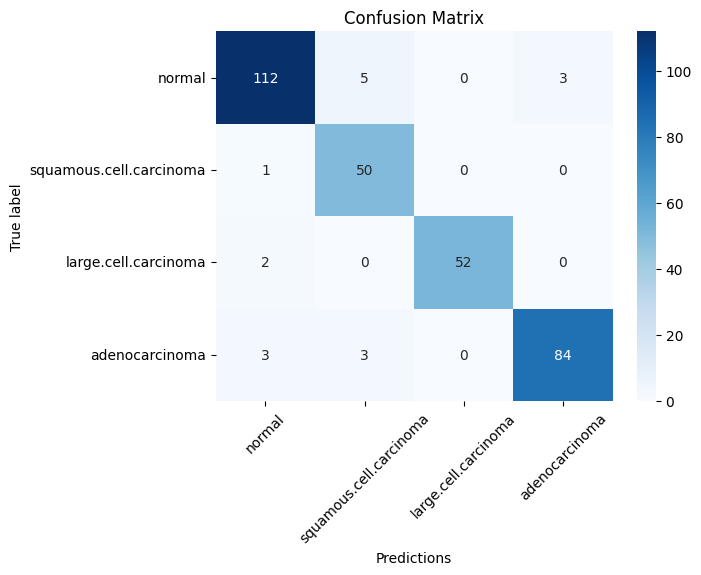

In [23]:
conf_mat = confusion_matrix(true_label,predictions)
sns.heatmap(conf_mat ,fmt='g',annot = True , cmap='Blues' , xticklabels=test_classes , yticklabels = test_classes,)
plt.xlabel('Predictions')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.xticks(rotation = 45)
plt.show()

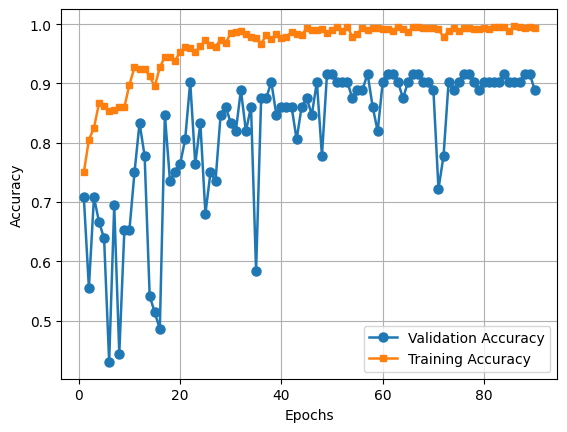

In [24]:
res = results1.history
train_acc = res['accuracy']
val_accuracy = res['val_accuracy']
epochs = range(1, len(train_acc) + 1)

line1 = plt.plot(epochs, val_accuracy, label = 'Validation Accuracy')
line2 = plt.plot(epochs, train_acc, label = 'Training Accuracy')

plt.setp(line1, linewidth = 1.8, marker = 'o', markersize = 6.5)
plt.setp(line2, linewidth = 1.8, marker = 's', markersize = 5)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

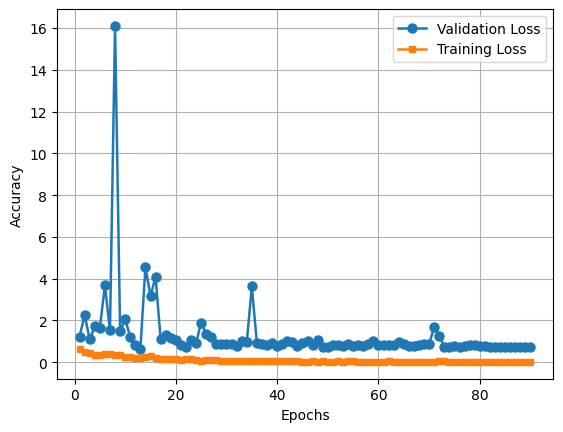

In [25]:
res = results1.history
train_loss = res['loss']
val_loss = res['val_loss']
epochs = range(1, len(train_loss) + 1)

line1 = plt.plot(epochs, val_loss, label = 'Validation Loss')
line2 = plt.plot(epochs, train_loss, label = 'Training Loss')

plt.setp(line1, linewidth = 1.8, marker = 'o', markersize = 6.5)
plt.setp(line2, linewidth = 1.8, marker = 's', markersize = 5)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()